# Qwen3.5-2B fine tuning on quote generation

Qwen3.5-2B is a pre-trained instruct SLM. The target is to teach it generate quotes in Russian.

## Setup

The stack below covers training, Hub upload, plotting, and GPU telemetry.

In [ ]:
!pip install -U pip setuptools wheel
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130
!pip install -U "transformers>=4.52.0" accelerate peft trl datasets huggingface_hub pandas matplotlib nvidia-ml-py tensorboard sentencepiece protobuf safetensors psutil

## Imports and configuration

In [ ]:
import os
import sys
import json
import time
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pynvml
from tqdm import tqdm

from datasets import load_dataset
from huggingface_hub import HfApi, login, upload_folder
from accelerate import notebook_launcher
from peft import LoraConfig, PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

sys.path.insert(0, str(Path.cwd()))

from train_helpers import (
    GPUStatsLogger,
    HistoryStore,
    GPUAndHistoryCallback,
    ensure_dir,
    set_seed,
    save_json,
    token_length_stats,
    print_cuda_rows,
    plot_histogram,
    plot_lines,
    save_trainer_history,
)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

seed = 3407
base_model_id = "Qwen/Qwen3.5-2B"
dataset_id = "pymlex/wolf-quotes"
hub_model_id = "pymlex/qwen3.5-2b-wolflm"

run_dir = Path('./qwen_quotes_cpt_run')
adapter_dir = run_dir / 'adapter'
publish_dir = run_dir / 'publish'
plots_dir = run_dir / 'plots'
run_dir.mkdir(parents=True, exist_ok=True)
adapter_dir.mkdir(parents=True, exist_ok=True)
publish_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

set_seed(seed)

import pynvml

pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)
info = pynvml.nvmlDeviceGetMemoryInfo(handle)
name = pynvml.nvmlDeviceGetName(handle)

print(f"GPU: {name}")
print(f"Total Memory: {info.total / 1024**2:} MB")

pynvml.nvmlShutdown()

print(f"base_model_id: {base_model_id}")
print(f"dataset_id: {dataset_id}")
print(f"hub_model_id: {hub_model_id}")

GPU: NVIDIA GeForce RTX 5090
Total Memory: 32607.0 MB
base_model_id: Qwen/Qwen3.5-2B
dataset_id: pymlex/wolf-quotes
hub_model_id: pymlex/qwen3-5-2b-wolflm


## Tokenizer and dataset

The corpus is plain text. Each quote is finished with EOS and the token length is tracked before training.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    trust_remote_code=True,
    use_fast=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = 'right'

raw = load_dataset(dataset_id)
filtered = raw['train'].filter(
    lambda example: len(
        tokenizer(
            str(example['quote']).strip(),
            add_special_tokens=False,
        )['input_ids']
    ) < 64
)

train_raw = filtered.shuffle(seed=seed)
split = train_raw.train_test_split(
    test_size=0.05,
    seed=seed,
)
train_base = split['train']
val_base = split['test']


def build_text(example):
    quote = str(example['quote']).strip()

    if not quote:
        return {'text': '', 'n_tokens': 0}

    messages = [
        {
            'role': 'user',
            'content': 'Напиши короткую глубокую цитату.',
        },
        {
            'role': 'assistant',
            'content': quote,
        },
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    token_count = len(
        tokenizer(
            text,
            add_special_tokens=False,
        )['input_ids']
    )

    return {
        'text': text,
        'n_tokens': token_count,
    }


train_ds = train_base.map(
    build_text,
    remove_columns=train_base.column_names,
)

val_ds = val_base.map(
    build_text,
    remove_columns=val_base.column_names,
)

print(train_base)
print(val_base)

Dataset({
    features: ['quote'],
    num_rows: 89669
})
Dataset({
    features: ['quote'],
    num_rows: 4720
})


In [ ]:
print(train_ds[0]['text'])
print(len(train_ds), len(val_ds))

<|im_start|>user
Напиши короткую глубокую цитату.<|im_end|>
<|im_start|>assistant
<think>

</think>

Красивая внешность есть у многих, а красивая душа - не у каждого.<|im_end|>

89669 4720


## Token lengths

The histogram below shows how much context the model sees per sample. Quotes stay short, so packing is a good fit.


In [ ]:
all_lengths = list(train_ds['n_tokens']) + list(val_ds['n_tokens'])
length_stats = token_length_stats(all_lengths)
length_stats

{'count': 94389,
 'min': 31,
 'max': 89,
 'mean': 50.6553517888737,
 'median': 48.0,
 'p95': 72.0,
 'p99': 82.0}

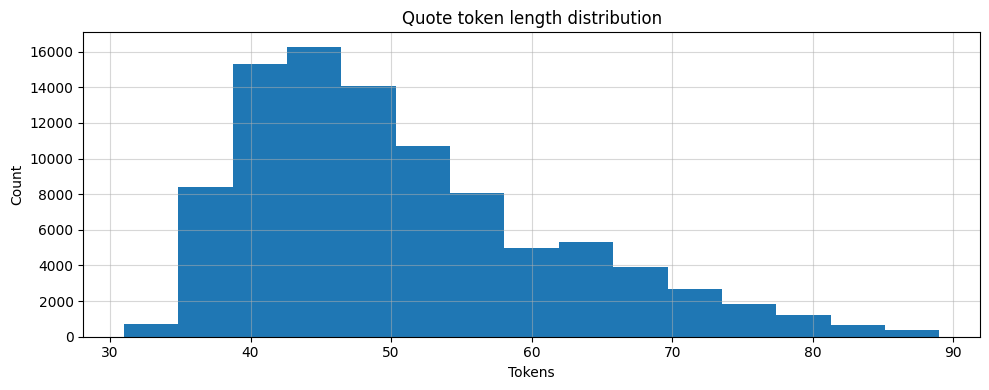

In [ ]:
plot_histogram(
    all_lengths,
    title='Quote token length distribution',
    xlabel='Tokens',
    ylabel='Count',
    path=plots_dir / 'token_lengths.png',
    bins=15,
)

## Training

The model learns plain continuation on quote text. No instructions, no template, no extra tags.


In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
)

history_store = HistoryStore(run_dir)
gpu_logger = GPUStatsLogger()

bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
fp16 = torch.cuda.is_available() and not bf16


def train_worker():
    local_tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True, use_fast=True)
    if local_tokenizer.pad_token is None:
        local_tokenizer.pad_token = local_tokenizer.eos_token
    local_tokenizer.padding_side = 'right'

    local_raw = load_dataset(dataset_id)
    local_train = local_raw['train'].shuffle(seed=seed)
    local_split = local_train.train_test_split(test_size=0.05, seed=seed)
    local_train_base = local_split['train']
    local_val_base = local_split['test']

    def local_build_text(example):
        quote = str(example['quote']).strip()

        if not quote:
            return {'text': '', 'n_tokens': 0}

        messages = [
            {
                'role': 'user',
                'content': 'Напиши короткую глубокую цитату.',
            },
            {
                'role': 'assistant',
                'content': quote,
            },
        ]

        text = local_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )

        token_count = len(
            local_tokenizer(
                text,
                add_special_tokens=False,
            )['input_ids']
        )

        return {
            'text': text,
            'n_tokens': token_count,
        }

    local_train_ds = local_train_base.map(local_build_text, remove_columns=local_train_base.column_names)
    local_val_ds = local_val_base.map(local_build_text, remove_columns=local_val_base.column_names)

    model = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        trust_remote_code=True,
        torch_dtype=torch.bfloat16 if bf16 else torch.float16,
        low_cpu_mem_usage=True,
        attn_implementation='sdpa',
    )
    model.config.use_cache = False
    model.gradient_checkpointing_enable()

    training_args = SFTConfig(
        output_dir=str(adapter_dir),
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        gradient_accumulation_steps=1,
        num_train_epochs=1,
        learning_rate=1e-4,
        warmup_ratio=0.03,
        lr_scheduler_type='cosine',
        lr_scheduler_kwargs={'num_cycles': 0.35},
        weight_decay=0.01,
        optim='adamw_torch',
        logging_strategy='steps',
        logging_steps=1,
        eval_strategy='steps',
        eval_steps=20,
        save_strategy='steps',
        save_steps=100,
        save_total_limit=2,
        bf16=bf16,
        fp16=fp16,
        gradient_checkpointing=True,
        report_to='tensorboard',
        seed=seed,
        packing=True,
        dataset_text_field='text',
        max_length=96,
        remove_unused_columns=False,
        ddp_find_unused_parameters=False,
        dataloader_num_workers=4,
        logging_first_step=True,
        eval_on_start=True,
    )

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=local_train_ds,
        eval_dataset=local_val_ds,
        peft_config=lora_config,
        processing_class=local_tokenizer,
    )

    callback = GPUAndHistoryCallback(history_store, gpu_logger=gpu_logger)
    trainer.add_callback(callback)
    trainer.train()

    if trainer.is_world_process_zero():
        trainer.save_model(str(adapter_dir))
        local_tokenizer.save_pretrained(str(adapter_dir))
        save_trainer_history(trainer, run_dir)
        history_store.save_csv()

In [ ]:
notebook_launcher(train_worker, num_processes=1)

Launching training on one GPU.


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_a

Step,Training Loss,Validation Loss
0,No log,4.777027
20,1.697621,1.685282
40,1.526508,1.534648
60,1.537554,1.509073
80,1.493362,1.494412
100,1.457089,1.483334
120,1.553864,1.472981
140,1.468368,1.465306
160,1.408955,1.457559
180,1.380794,1.451668


step 0 | eval_loss 4.7770 | GPU 90.43% | VRAM 11.41%
step 1 | loss 4.7507 | GPU 76.57% | VRAM 11.77%
step 2 | loss 4.5508 | GPU 93.4% | VRAM 11.77%
step 3 | loss 4.8113 | GPU 93.4% | VRAM 11.77%
step 4 | loss 4.7521 | GPU 93.4% | VRAM 11.77%
step 5 | loss 4.7307 | GPU 93.4% | VRAM 11.77%
step 6 | loss 4.5842 | GPU 77.26% | VRAM 11.77%
step 7 | loss 4.2785 | GPU 77.26% | VRAM 11.77%
step 8 | loss 3.9728 | GPU 77.26% | VRAM 11.77%
step 9 | loss 3.5934 | GPU 93.91% | VRAM 11.77%
step 10 | loss 3.1513 | GPU 93.91% | VRAM 11.77%
step 11 | loss 2.8556 | GPU 93.91% | VRAM 11.77%
step 12 | loss 2.6227 | GPU 93.91% | VRAM 11.77%
step 13 | loss 2.5107 | GPU 93.91% | VRAM 11.77%
step 14 | loss 2.4638 | GPU 93.91% | VRAM 11.77%
step 15 | loss 2.1843 | GPU 93.91% | VRAM 11.77%
step 16 | loss 2.1421 | GPU 93.91% | VRAM 11.77%
step 17 | loss 1.9924 | GPU 77.34% | VRAM 11.77%
step 18 | loss 1.8117 | GPU 77.34% | VRAM 11.77%
step 19 | loss 1.9272 | GPU 77.34% | VRAM 11.77%
step 20 | loss 1.6976 | GPU 7

## Logs and plots

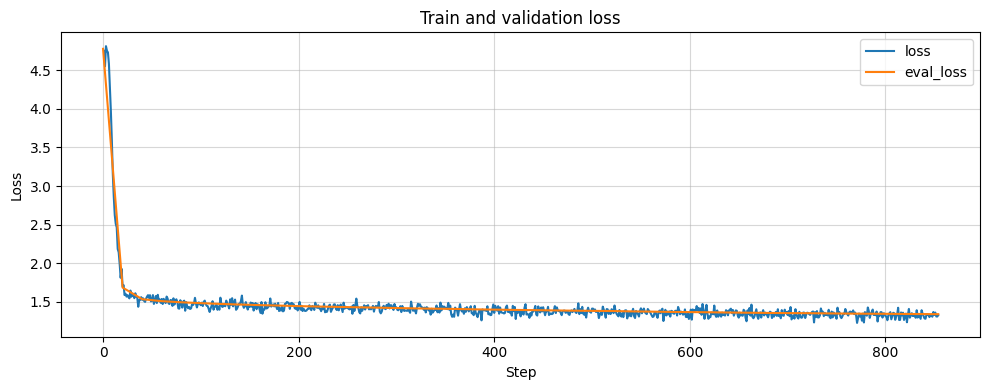

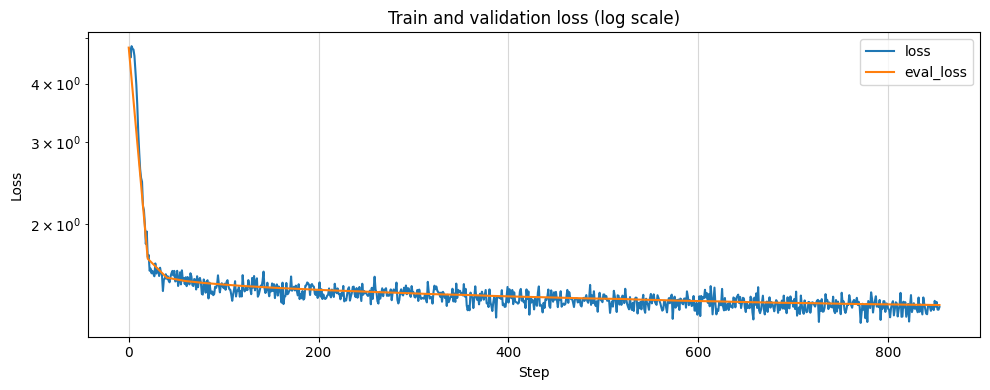

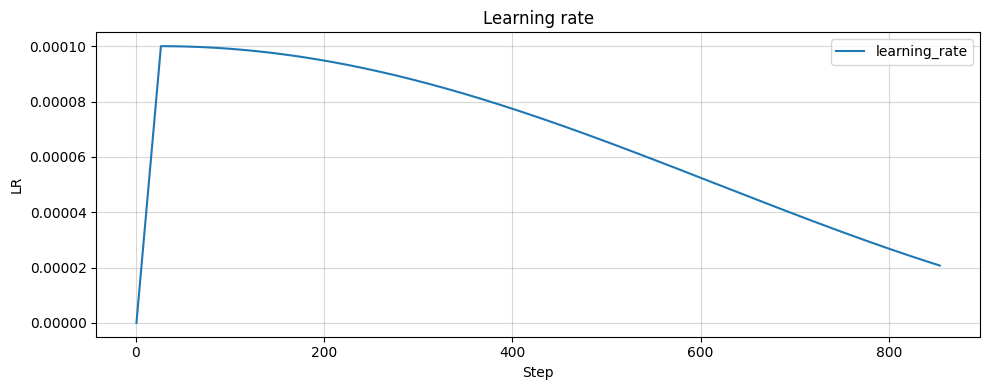

In [ ]:
import json
import pandas as pd
from pathlib import Path

trainer_state_path = plots_dir.parent / "trainer_state_history.json"

with open(trainer_state_path, "r", encoding="utf-8") as f:
    log_history = json.load(f)

history_df = pd.DataFrame(log_history)

history_df = history_df.sort_values("step").reset_index(drop=True)

plot_lines(
    history_df,
    x='step',
    ys=['loss', 'eval_loss'],
    title='Train and validation loss',
    xlabel='Step',
    ylabel='Loss',
    path=plots_dir / 'loss_curve.png',
)

plot_lines(
    history_df,
    x='step',
    ys=['loss', 'eval_loss'],
    title='Train and validation loss (log scale)',
    xlabel='Step',
    ylabel='Loss',
    path=plots_dir / 'loss_curve_log.png',
    log_y=True,
)

plot_lines(
    history_df,
    x='step',
    ys=['learning_rate'],
    title='Learning rate',
    xlabel='Step',
    ylabel='LR',
    path=plots_dir / 'learning_rate.png',
)

## Publish

The trained LoRA adapter is uploaded to the Hub.

In [ ]:
import shutil

tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

publish_dir.mkdir(parents=True, exist_ok=True)

keep_names = {
    'adapter_config.json',
    'adapter_model.safetensors',
    'adapter_model.bin',
    'special_tokens_map.json',
    'tokenizer.json',
    'tokenizer_config.json',
    'tokenizer.model',
    'tokenizer.vocab',
    'generation_config.json',
}

for item in publish_dir.iterdir():
    if item.is_file() or item.is_symlink():
        item.unlink()
    elif item.is_dir():
        shutil.rmtree(item)

for item in adapter_dir.iterdir():
    if item.is_file() and item.name in keep_names:
        shutil.copy2(item, publish_dir / item.name)

login(token='YOUR_TOKEN')
api = HfApi()
api.create_repo(repo_id=hub_model_id, repo_type='model', exist_ok=True)
upload_folder(
    repo_id=hub_model_id,
    folder_path=str(publish_dir),
    repo_type='model',
    commit_message='Upload LoRA adapter',
)

print(hub_model_id)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

pymlex/qwen3-5-2b-wolflm


## Inference from Hub

Daily use code for Google Colab.

In [ ]:
!pip install --upgrade transformers torchao

In [7]:
import re
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

base_model_id = "Qwen/Qwen3.5-2B"
adapter_hub_id = "pymlex/qwen3.5-2b-wolflm"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(base_model, adapter_hub_id)
model.eval()

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3_5ForCausalLM(
      (model): Qwen3_5TextModel(
        (embed_tokens): Embedding(248320, 2048)
        (layers): ModuleList(
          (0-2): 3 x Qwen3_5DecoderLayer(
            (linear_attn): Qwen3_5GatedDeltaNet(
              (act): SiLUActivation()
              (conv1d): Conv1d(6144, 6144, kernel_size=(4,), stride=(1,), padding=(3,), groups=6144, bias=False)
              (norm): Qwen3_5RMSNormGated()
              (out_proj): Linear(in_features=2048, out_features=2048, bias=False)
              (in_proj_qkv): Linear(in_features=2048, out_features=6144, bias=False)
              (in_proj_z): Linear(in_features=2048, out_features=2048, bias=False)
              (in_proj_b): Linear(in_features=2048, out_features=16, bias=False)
              (in_proj_a): Linear(in_features=2048, out_features=16, bias=False)
            )
            (mlp): Qwen3_5MLP(
              (gate_proj): lora.Linear(
                (base_la

In [8]:
def generate_quote(max_new_tokens=100, temperature=0.9, top_p=0.9):
    messages = [{"role": "user", "content": "Напиши короткую глубокую цитату."}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    full_response = tokenizer.decode(outputs[0], skip_special_tokens=False)
    assistant_part = full_response.split("<|im_start|>assistant")[1].split("<|im_end|>")[0].strip()
    assistant_part = re.sub(r"<think>.*?</think>", "", assistant_part, flags=re.DOTALL).strip()
    return assistant_part

    return assistant_part

In [11]:
print(generate_quote())

Если человек мне не нужен, я не спрашиваю "а почему?"


## Metrics

Loss on the test set and perplexity.

In [ ]:
import math
import torch
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from tqdm import tqdm
from torch.utils.data import DataLoader

base_model_id = "Qwen/Qwen3.5-2B"
adapter_hub_id = "pymlex/qwen3.5-2b-wolflm"
dataset_id = "pymlex/wolf-quotes"
batch_size = 8
max_length = 96
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

In [ ]:
raw = load_dataset(dataset_id)
filtered = raw['train'].filter(
    lambda example: len(
        tokenizer(str(example['quote']).strip(), add_special_tokens=False)['input_ids']
    ) < 64
)
split = filtered.train_test_split(test_size=0.05, seed=3407)
val_base = split['test']

def build_text(example):
    quote = str(example['quote']).strip()
    if not quote:
        return {'text': ''}
    messages = [
        {"role": "user", "content": "Напиши короткую глубокую цитату."},
        {"role": "assistant", "content": quote},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {'text': text}

val_ds = val_base.map(build_text, remove_columns=val_base.column_names)

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=max_length, padding='max_length', return_attention_mask=True)

tokenized_val = val_ds.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized_val.set_format(type='torch', columns=['input_ids', 'attention_mask'])
dataloader = DataLoader(tokenized_val, batch_size=batch_size, shuffle=False)

def compute_average_loss(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            num_tokens = attention_mask.sum().item()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens
    return total_loss / total_tokens

README.md: 0.00B [00:00, ?B/s]

wolf_quotes.csv:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/94946 [00:00<?, ? examples/s]

Filter:   0%|          | 0/94946 [00:00<?, ? examples/s]

Map:   0%|          | 0/4720 [00:00<?, ? examples/s]

Map:   0%|          | 0/4720 [00:00<?, ? examples/s]

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
base_model.eval()
base_loss = compute_average_loss(base_model, dataloader, device)
base_perplexity = math.exp(base_loss)

lora_model = PeftModel.from_pretrained(base_model, adapter_hub_id)
lora_model.eval()
lora_loss = compute_average_loss(lora_model, dataloader, device)
lora_perplexity = math.exp(lora_loss)

results_df = pd.DataFrame([
    {"Model": "Base Qwen3.5-2B", "Loss": base_loss, "Perplexity": base_perplexity},
    {"Model": "WolfLM", "Loss": lora_loss, "Perplexity": lora_perplexity},
])
print(results_df.to_string(index=False))

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 590/590 [02:34<00:00,  3.82it/s]

          Model     Loss  Perplexity
Base Qwen3.5-2B 2.774358   16.028341
         WolfLM 1.315702    3.727368
